# BT4222 GROUP 7: Twitter Bot Fraud Detection

## Initialising Edges, tweets, users metadata Files 

### Importing Libaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Final Dataset Before Graph Conversion

This section prepares the final user–user interaction dataset before converting it into a graph learning format.

The raw data contains multiple entity types, including users, tweets, lists, and hashtags. To make the data suitable for graph learning, this section transforms the original edge table into a unified multi-relational user–user edge list, where each directed edge represents a specific interaction between two users. These interactions include follow, like, mention, reply, retweet, quote, community-based relations, and usage of the same  hasthtags.

Rather than using the raw heterogeneous edge table directly, this implementation first resolves intermediate entities such as tweets and lists so that all final edges are expressed consistently as **user → relation → user**.

Pipeline:
1. Read and load the raw edge table, user metadata, list data, and hashtag data.
2. Standardise identifiers and split the raw edges by relation type.
3. Build a `tweet_to_user` mapping so tweet-level interactions can be traced back to the corresponding author.
4. Convert each interaction type into a user–user relation, including follows, likes, mentions, replies, retweets, quotes, community-based links and usage of the same hashtag.
5. Combine all relation-specific edge tables into one final `df_user_user_edges_all` dataset and filter the final edge list to retain only edges where atleast one endpoints belong to the 20k labelled user set.
6. Produce summary statistics and connectivity checks to validate the final dataset before graph conversion.

### Reading Files

In [2]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)

df_edges = pd.read_parquet("datasets/df_edges_final.parquet")
df_user = pd.read_parquet("datasets/df_user_meta_full.parquet")
df_list = pd.read_csv("datasets/list.csv")
df_hashtag = pd.read_json("datasets/hashtag.json")

### Display Rows

In [3]:
display(df_edges.head())

,source_id,target_id,relation
0,u148520716,u59653593,following
1,u1078324065532764166,u781676758932262912,following
2,u33746386,u22730752,following
3,u28896955,u1951553371,following
4,u3287999704,u1029392984842719233,followers


In [4]:
display(df_user.head())

,id,label,split,participation_degree,pinned_tweet_id,protected,verified,followers_count,following_count,tweet_count,listed_count,has_pinned_tweet,account_age_days,has_description,has_location,has_url,has_profile_image,profile_completeness_score,log_followers_following_ratio,log_following_followers_ratio,log_tweets_followers_ratio,log_tweets_following_ratio,log_listed_followers_ratio,log_normalized_followers,log_normalized_following,log_normalized_tweets,log_normalized_listed,average_tweets_per_day,log_tweets_per_day_relative_to_age,log_tweet_engagement_ratio,high_activity_low_followers,high_tweet_low_age,is_low_follower_high_activity,new_account_high_tweets,follows_more_than_followed,is_new_with_verified,account_age_category,description_length,username_length,description_word_count,has_url_in_description,username_digit_ratio,description_digit_ratio,description_special_chars_count,description_uppercase_ratio,username_special_chars_ratio,follower_following_disparity,description_spam_score,username_digit_count,username_upper_ratio,username_special_char_ratio,username_underscore_count,name_length,name_word_count,name_digit_count,name_upper_ratio,description_digit_count,description_upper_ratio,description_special_char_ratio,desc_tfidf_2021,desc_tfidf_2022,desc_tfidf_account,desc_tfidf_advice,desc_tfidf_advisor,desc_tfidf_advocate,desc_tfidf_ai,desc_tfidf_alum,desc_tfidf_ambassador,desc_tfidf_american,desc_tfidf_analysis,desc_tfidf_analyst,desc_tfidf_analytics,desc_tfidf_anti,desc_tfidf_art,desc_tfidf_artificial,desc_tfidf_artist,desc_tfidf_assistant,desc_tfidf_assistant professor,desc_tfidf_associate,desc_tfidf_associate professor,desc_tfidf_author,desc_tfidf_award,desc_tfidf_based,desc_tfidf_best,desc_tfidf_better,desc_tfidf_bitcoin,desc_tfidf_black,desc_tfidf_blockchain,desc_tfidf_blog,desc_tfidf_blogger,desc_tfidf_board,desc_tfidf_book,desc_tfidf_books,desc_tfidf_bot,desc_tfidf_brain,desc_tfidf_build,desc_tfidf_building,desc_tfidf_business,desc_tfidf_candidate,desc_tfidf_center,...,desc_tfidf_security,desc_tfidf_self,desc_tfidf_senior,desc_tfidf_service,desc_tfidf_services,desc_tfidf_share,desc_tfidf_sharing,desc_tfidf_social,desc_tfidf_social media,desc_tfidf_society,desc_tfidf_software,desc_tfidf_software engineer,desc_tfidf_solutions,desc_tfidf_source,desc_tfidf_space,desc_tfidf_speaker,desc_tfidf_sports,desc_tfidf_stanford,desc_tfidf_startups,desc_tfidf_state,desc_tfidf_student,desc_tfidf_studying,desc_tfidf_stuff,desc_tfidf_support,desc_tfidf_systems,desc_tfidf_teacher,desc_tfidf_team,desc_tfidf_tech,desc_tfidf_technology,desc_tfidf_things,desc_tfidf_time,desc_tfidf_tips,desc_tfidf_trader,desc_tfidf_travel,desc_tfidf_trying,desc_tfidf_tv,desc_tfidf_tweet,desc_tfidf_tweets,desc_tfidf_twitter,desc_tfidf_twitter account,desc_tfidf_uk,desc_tfidf_university,desc_tfidf_unknown,desc_tfidf_updates,desc_tfidf_views,desc_tfidf_vision,desc_tfidf_voice,desc_tfidf_way,desc_tfidf_web,desc_tfidf_website,desc_tfidf_winning,desc_tfidf_women,desc_tfidf_work,desc_tfidf_working,desc_tfidf_world,desc_tfidf_write,desc_tfidf_writer,desc_tfidf_writing,desc_tfidf_york,desc_tfidf_youtube,tweets,has_tweets,num_tweets,tweets_frequency,posting_regularity,avg_length_per_tweet,avg_words_per_tweet,avg_word_length_per_tweet,avg_uppercase_pct,avg_digit_pct,avg_special_char_pct,avg_emoji,avg_hashtags_per_tweet,overuse_hashtags,pct_tweets_with_hashtags,avg_mentions_per_tweet,pct_tweets_with_mentions,avg_urls_per_tweet,pct_tweets_with_urls,avg_attachments_per_tweet,pct_tweets_with_attachments,avg_sensitive,avg_positive,avg_negative,avg_neutral,avg_retweets,avg_quotes,avg_replies,avg_originals,avg_likes_per_tweet,avg_retweets_per_tweet,avg_replies_per_tweet,avg_quotes_per_tweet,engagement_rate,pct_allow_reply,fc_reply,num_unique_langs,pct_geo_tweets,has_reply_inconsistency,reply_inconsistency_count
0,u1217628182611927040,human,test,1893,NaN,0,0,7316,215,3098,69,0,765,1,1,1,1,4,3.522677,-3.522677,-0.859121,2.663556,-4.649460,2.255469,-1.267208,1.396348,-2.393992

In [5]:
display(df_list.head())

,id,name,created_at,description,follower_count,member_count,private,owner_id
0,l1128774,StimulatingBroadband.com,2009-10-30 14:38:00+00:00,Subscribe to our Twitter firehose of 500 telec...,35,452,False,32745876
1,l733341248057180166,Local news,2016-05-19 16:59:13+00:00,Follow for breaking news and updates in North ...,3,47,False,316508410
2,l7983816,Futerrans,2010-02-26 18:01:03+00:00,Futerra staff past and present,6,25,False,23102054
3,l7008265,Beautiful People,2010-02-07 13:40:48+00:00,People who are strong minded and stand up for ...,28,179,False,23246523
4,l6807414,celebrities,2010-02-03 09:56:17+00:00,NaN,7,6,False,16454856


In [6]:
display(df_hashtag.head())

,id,tag_name
0,h0,TheLegendofVoxMachina
1,h1,CriticalRoleSpoilers
2,h2,LVMSpoilers
3,h3,wip
4,h4,criticalrolefanart


## Spliting the raw edges by interaction by relation type

In [7]:
# Keep ids as strings
df_edges = df_edges.copy()
df_user = df_user.copy()
df_list = df_list.copy()
valid_users = set(df_user["id"])

# Split the existing edge table by relation
df_following_base   = df_edges[df_edges["relation"] == "following"].copy()
df_follower_base    = df_edges[df_edges["relation"] == "followed"].copy()
df_post_base        = df_edges[df_edges["relation"] == "post"].copy()
df_like_base        = df_edges[df_edges["relation"] == "like"].copy()
df_own_base         = df_edges[df_edges["relation"] == "own"].copy()
df_contain_base     = df_edges[df_edges["relation"] == "contain"].copy()
df_mentions_base    = df_edges[df_edges["relation"] == "mentioned"].copy()
df_replies_base     = df_edges[df_edges["relation"] == "replied_to"].copy()
df_retweets_base    = df_edges[df_edges["relation"] == "retweeted"].copy()
df_quotes_base      = df_edges[df_edges["relation"] == "quoted"].copy()
df_pinned_base      = df_edges[df_edges["relation"] == "pinned"].copy()
df_membership_base  = df_edges[df_edges["relation"] == "membership"].copy()
df_discuss_base     = df_edges[df_edges["relation"] == "discuss"].copy()

print("following:",     df_following_base.shape)
print("follower:",      df_follower_base.shape)
print("post:",          df_post_base.shape)
print("like:",          df_like_base.shape)
print("own:",           df_own_base.shape)
print("contain:",       df_contain_base.shape)
print("mentions:",      df_mentions_base.shape)
print("replies_to:",    df_replies_base.shape)
print("retweets:",      df_retweets_base.shape)
print("quotes:",        df_quotes_base.shape)
print("pinned:",        df_pinned_base.shape)
print("membership:",    df_membership_base.shape)
print("discuss:",       df_discuss_base.shape)


following: (197990, 3)
follower: (17346, 3)
post: (5797761, 3)
like: (203642, 3)
own: (2874, 3)
contain: (1562941, 3)
mentions: (849521, 3)
replies_to: (489842, 3)
retweets: (740414, 3)
quotes: (135434, 3)
pinned: (9120, 3)
membership: (102436, 3)
discuss: (4970315, 3)


## Build mapping from "user -> tweet -> user" for easy authorship retrieval

In [8]:
tweet_to_user = (
    df_post_base[["source_id", "target_id"]]
    .drop_duplicates()
    .rename(columns={"source_id": "author_user_id", "target_id": "tweet_id"})
)

tweet_to_user["author_user_id"] = tweet_to_user["author_user_id"].astype(str)
tweet_to_user["tweet_id"] = tweet_to_user["tweet_id"].astype(str)

tweet_to_user_map = dict(zip(tweet_to_user["tweet_id"], tweet_to_user["author_user_id"]))

print("tweet_to_user from post edges:", len(tweet_to_user_map))
tweet_to_user.head()

tweet_to_user from post edges: 5797761


,author_user_id,tweet_id
242793,u48390963,t1480809188880175108
242794,u368644797,t1455239713267363849
242795,u904794157,t1499039530996879361
242796,u493482998,t1488474786149847041
242797,u2882501298,t1491697289026486277


## Converting each interaction type into a user-user relation
### 1) user -> follows -> user

In [9]:
df_followers_flipped = (
    df_follower_base[["source_id", "target_id"]]
    .rename(columns={"source_id": "target_id", "target_id": "source_id"})
    [["source_id", "target_id"]]
    .copy()
)

df_following_all = pd.concat([
    df_following_base[["source_id", "target_id"]].copy(),
    df_followers_flipped
], ignore_index=True)

df_following_all["source_id"] = df_following_all["source_id"].astype(str)
df_following_all["target_id"] = df_following_all["target_id"].astype(str)
df_following_all["relation"] = "following"

df_follows = df_following_all[
    df_following_all["source_id"] != df_following_all["target_id"]
][["source_id", "target_id", "relation"]].drop_duplicates()

print(df_follows.shape)
df_follows.head()

(215336, 3)


,source_id,target_id,relation
0,u148520716,u59653593,following
1,u1078324065532764166,u781676758932262912,following
2,u33746386,u22730752,following
3,u28896955,u1951553371,following
4,u625655093,u141163282,following


### 2) user -> likes -> user

In [10]:
df_likes_user = (
    df_like_base[["source_id", "target_id"]]
    .rename(columns={"source_id": "source_id", "target_id": "tweet_id"})
    .assign(target_id=lambda x: x["tweet_id"].astype(str).map(tweet_to_user_map))
    .dropna(subset=["target_id"])
)
df_likes_user["relation"] = "likes"

df_likes_user = df_likes_user[
    df_likes_user["source_id"] != df_likes_user["target_id"]
][["source_id", "target_id", "relation"]].drop_duplicates()

print(df_likes_user.shape)
df_likes_user.head()

(22913, 3)


,source_id,target_id,relation
13423336,u2248919588,u51310666,likes
13423343,u1111600251939377152,u848081553368416256,likes
13423344,u287156977,u18839785,likes
13423361,u56780944,u816653,likes
13423362,u72448544,u1036997113274662920,likes


### 3) user -> owner_of_communities_frequent_by -> user

In [11]:
# own = user -> list
df_own_links = df_own_base[["source_id", "target_id"]].copy()
df_own_links.columns = ["owner_user_id", "list_id"]

#contain = list -> tweet
df_contain_links = df_contain_base[["source_id", "target_id"]].copy()
df_contain_links.columns = ["list_id", "tweet_id"]

# post = user -> list -> tweet -> user
df_post_links = df_post_base[["source_id", "target_id"]].copy()
df_post_links.columns = ["author_user_id", "tweet_id"]

# user -> tweet ->
df_list_owner_to_user = (
    df_own_links
    .merge(df_contain_links, on="list_id", how="inner")
    .merge(df_post_links, on="tweet_id", how="inner")
)

#Drop any self loops
df_list_owner_to_user = df_list_owner_to_user[
    (df_list_owner_to_user["owner_user_id"] != df_list_owner_to_user["author_user_id"])
].copy()

# final format (user - user)
df_list_owner_to_user = df_list_owner_to_user.rename(columns={
    "owner_user_id": "source_id",
    "author_user_id": "target_id"
})[["source_id", "target_id"]]

df_list_owner_to_user["relation"] = "owner_of_communities_frequent_by"
df_list_owner_to_user = df_list_owner_to_user.drop_duplicates()

print(df_list_owner_to_user.shape)
df_list_owner_to_user.head()

(4141, 3)


,source_id,target_id,relation
3,u20147960,u731808469301493760,owner_of_communities_frequent_by
15,u20147960,u16692909,owner_of_communities_frequent_by
42,u20147960,u17663776,owner_of_communities_frequent_by
44,u25660512,u14293310,owner_of_communities_frequent_by
45,u25660512,u8942262,owner_of_communities_frequent_by


### 4) user -> mentions -> user

In [12]:
df_mentions_user = df_mentions_base[["source_id", "target_id"]].copy()
df_mentions_user = df_mentions_user.rename(columns={"source_id": "mentioning_tweet_id"})

df_mentions_user["source_id"] = df_mentions_user["mentioning_tweet_id"].map(tweet_to_user_map)
df_mentions_user["relation"] = "mentions"

df_mentions_user = df_mentions_user[
    df_mentions_user["source_id"].notna() &
    (df_mentions_user["source_id"] != df_mentions_user["target_id"])
][["source_id", "target_id", "relation"]].drop_duplicates()

print(df_mentions_user.shape)
df_mentions_user.head()

(98907, 3)


,source_id,target_id,relation
12573814,u360540433,u1381505906,mentions
12573815,u819756020197167104,u18839785,mentions
12573816,u43963249,u252249233,mentions
12573822,u202982523,u977584704500224001,mentions
12573823,u102708234,u16984977,mentions


### 5) user -> replies_to -> user

In [13]:
df_replies_user = df_replies_base[["source_id", "target_id"]].copy()
df_replies_user = df_replies_user.rename(columns={
    "source_id": "reply_tweet_id",
    "target_id": "replied_to_tweet_id"
})

df_replies_user["source_id"] = df_replies_user["reply_tweet_id"].map(tweet_to_user_map)
df_replies_user["target_id"] = df_replies_user["replied_to_tweet_id"].map(tweet_to_user_map)
df_replies_user["relation"] = "replies_to"

df_replies_user = df_replies_user[
    df_replies_user["source_id"].notna() &
    df_replies_user["target_id"].notna() &
    (df_replies_user["source_id"] != df_replies_user["target_id"])
][["source_id", "target_id", "relation"]].drop_duplicates()

print(df_replies_user.shape)
df_replies_user.head()

(20590, 3)


,source_id,target_id,relation
13644330,u223105455,u19985444,replies_to
13644338,u1157604793,u1329262027,replies_to
13644353,u90570778,u44196397,replies_to
13644375,u1601593543,u38174427,replies_to
13644382,u269873890,u1163992520252153857,replies_to


### 6) user -> retweets -> user

In [14]:
df_retweets_user = df_retweets_base[["source_id", "target_id"]].copy()
df_retweets_user = df_retweets_user.rename(columns={
    "source_id": "retweet_tweet_id",
    "target_id": "retweeted_tweet_id"
})

df_retweets_user["source_id"] = df_retweets_user["retweet_tweet_id"].map(tweet_to_user_map)
df_retweets_user["target_id"] = df_retweets_user["retweeted_tweet_id"].map(tweet_to_user_map)
df_retweets_user["relation"] = "retweets"

df_retweets_user = df_retweets_user[
    df_retweets_user["source_id"].notna() &
    df_retweets_user["target_id"].notna() &
    (df_retweets_user["source_id"] != df_retweets_user["target_id"])
][["source_id", "target_id", "relation"]].drop_duplicates()

print(df_retweets_user.shape)
df_retweets_user.head()

(44973, 3)


,source_id,target_id,relation
13644323,u36876992,u2869101210,retweets
13644341,u2240601558,u6466252,retweets
13644357,u607242831,u177547780,retweets
13644381,u2779511456,u14800270,retweets
13644397,u1271656262,u31656892,retweets


### 7) user -> quotes -> user

In [15]:
df_quotes_user = df_quotes_base[["source_id", "target_id"]].copy()
df_quotes_user = df_quotes_user.rename(columns={
    "source_id": "quote_tweet_id",
    "target_id": "quoted_tweet_id"
})

df_quotes_user["source_id"] = df_quotes_user["quote_tweet_id"].map(tweet_to_user_map)
df_quotes_user["target_id"] = df_quotes_user["quoted_tweet_id"].map(tweet_to_user_map)
df_quotes_user["relation"] = "quotes"

df_quotes_user = df_quotes_user[
    df_quotes_user["source_id"].notna() &
    df_quotes_user["target_id"].notna() &
    (df_quotes_user["source_id"] != df_quotes_user["target_id"])
][["source_id", "target_id", "relation"]].drop_duplicates()

print(df_quotes_user.shape)
df_quotes_user.head()

(12930, 3)


,source_id,target_id,relation
13644520,u43996441,u275686563,quotes
13644574,u993534145,u135647562,quotes
13644578,u72913875,u821102114,quotes
13644594,u18587457,u14552720,quotes
13644799,u162293874,u232294292,quotes


### 8) user -> member_of_communities_owned_by -> user

In [16]:
df_membership_to_owner = (
    df_membership_base[["source_id", "target_id"]]
    .rename(columns={"source_id": "list_id", "target_id": "source_id"})
    .merge(
        df_own_base[["source_id", "target_id"]]
        .rename(columns={"source_id": "target_id", "target_id": "list_id"}),
        on="list_id",
        how="inner"
    )
    .copy()
)

df_membership_to_owner["relation"] = "member_of_communities_owned_by"

df_membership_to_owner = df_membership_to_owner[
    df_membership_to_owner["source_id"] != df_membership_to_owner["target_id"]
][["source_id", "target_id", "relation"]].drop_duplicates()

print(df_membership_to_owner.shape)
df_membership_to_owner.head()

(10626, 3)


,source_id,target_id,relation
0,u2239670346,u8919762,member_of_communities_owned_by
1,u15823641,u784597005825871876,member_of_communities_owned_by
2,u1123336792021897216,u16621479,member_of_communities_owned_by
4,u1023072078,u76133155,member_of_communities_owned_by
5,u1769551,u11735032,member_of_communities_owned_by


### 9) user -> discusses_same_topics -> user

In [17]:
df_discuss_user = df_discuss_base[["source_id", "target_id"]].copy()
df_discuss_user["source_id"] = (
    df_discuss_user["source_id"]
    .astype(str)
    .map(tweet_to_user_map)
)

# Remove unmapped tweets and duplicates
df_discuss_user = df_discuss_user.dropna(subset=["source_id", "target_id"]).drop_duplicates()

# process and create pairs
def generate_pairs_for_hashtag(group):
    users = group.to_numpy()
    # Create pairs without storing all pairs in memory
    for i in range(len(users)):
        for j in range(i + 1, len(users)):
            yield {"source_id": users[i], "target_id": users[j]}

# Initialise list to store edges
df_topics_user_parts = []

# Process each hashtag group individually (without the max user limit)
for hashtag_id, group in df_discuss_user.groupby("target_id")["source_id"]:
    df_topics_user_parts.extend(generate_pairs_for_hashtag(group))

# Create DataFrame from the generator of pairs
df_topics_user = pd.DataFrame(df_topics_user_parts)

# Create reverse edges by using the same pairs
df_topics_user_rev = df_topics_user.rename(columns={"source_id": "target_id", "target_id": "source_id"})
df_topics_user = pd.concat([df_topics_user, df_topics_user_rev], ignore_index=True)

df_topics_user["relation"] = "discuss_same_topic"
df_topics_user = df_topics_user.drop_duplicates()

print(df_topics_user.shape)
df_topics_user.head()

(43563900, 3)


,source_id,target_id,relation
0,u3159148494,u786293766,discuss_same_topic
1,u3159148494,u24595522,discuss_same_topic
2,u3159148494,u94391895,discuss_same_topic
3,u3159148494,u280634176,discuss_same_topic
4,u3159148494,u442453551,discuss_same_topic


### Combining all edge df into one final df and ensuring all edges are one-hop away (either source or target are part of 20k labelled user set)

In [18]:
df_user_user_edges_all = pd.concat([
    df_follows,
    df_likes_user,
    df_list_owner_to_user,
    df_mentions_user,
    df_replies_user,
    df_retweets_user,
    df_quotes_user,
    df_membership_to_owner,
    df_topics_user
], ignore_index=True)

print(df_user_user_edges_all.shape)
print(df_user_user_edges_all["relation"].value_counts())

(43994316, 3)
relation
discuss_same_topic                  43563900
following                             215336
mentions                               98907
retweets                               44973
likes                                  22913
replies_to                             20590
quotes                                 12930
member_of_communities_owned_by         10626
owner_of_communities_frequent_by        4141
Name: count, dtype: int64


In [19]:
users_20k_ids = set(df_user["id"])

df_user_user_edges_all = df_user_user_edges_all[
    df_user_user_edges_all["source_id"].isin(users_20k_ids) |
    df_user_user_edges_all["target_id"].isin(users_20k_ids)
]

In [20]:
df_user_user_edges_all

,source_id,target_id,relation
0,u148520716,u59653593,following
1,u1078324065532764166,u781676758932262912,following
2,u33746386,u22730752,following
3,u28896955,u1951553371,following
4,u625655093,u141163282,following
...,...,...,...
43994311,u1366099459415945217,u203530201,discuss_same_topic
43994312,u29678151,u1070877486,discuss_same_topic
43994313,u29678151,u25048816,discuss_same_topic
43994314,u1366099459415945217,u29678151,discuss_same_topic


## Summary Statistics and Connectivitiy Checks

In [21]:
print("=" * 50)
print("GRAPH EDGE SUMMARY")
print("=" * 50)

print(f"\nTotal edge rows:      {df_user_user_edges_all.shape[0]:,}")
print(f"Unique source users:  {df_user_user_edges_all['source_id'].astype(str).nunique():,}")
print(f"Unique target users:  {df_user_user_edges_all['target_id'].astype(str).nunique():,}")
print(
    f"Unique users overall (including one-hop neighbours): "
    f"{pd.concat([df_user_user_edges_all['source_id'].astype(str), df_user_user_edges_all['target_id'].astype(str)]).nunique():,}"
)

# Unique edge triples and multiplicity
edge_multiplicity = (
    df_user_user_edges_all
    .assign(
        source_id=df_user_user_edges_all["source_id"].astype(str),
        target_id=df_user_user_edges_all["target_id"].astype(str)
    )
    .groupby(["source_id", "target_id", "relation"])
    .size()
    .reset_index(name="multiplicity")
)

print(f"\nUnique (source, target, relation) edges: {edge_multiplicity.shape[0]:,}")
print(f"Duplicate edge rows preserved:           {df_user_user_edges_all.shape[0] - edge_multiplicity.shape[0]:,}")

print("\n" + "=" * 50)
print("RELATION TYPE DISTRIBUTION")
print("=" * 50)

relation_stats = (
    edge_multiplicity
    .groupby("relation")
    .agg(
        unique_edge_count=("multiplicity", "count"),
        total_edge_rows=("multiplicity", "sum"),
        mean_multiplicity=("multiplicity", "mean"),
        median_multiplicity=("multiplicity", "median"),
        max_multiplicity=("multiplicity", "max"),
    )
    .sort_values("total_edge_rows", ascending=False)
)

relation_stats["edge_row_pct"] = (
    relation_stats["total_edge_rows"] / relation_stats["total_edge_rows"].sum() * 100
).round(2)

relation_stats["mean_multiplicity"] = relation_stats["mean_multiplicity"].round(2)

print(relation_stats.to_string())

print("\n" + "=" * 50)
print("OVERALL MULTIPLICITY DISTRIBUTION")
print("=" * 50)
print(edge_multiplicity["multiplicity"].describe().round(2).to_string())

print("\n" + "=" * 50)
print("MULTIPLICITY DISTRIBUTION BUCKETS")
print("=" * 50)

bins = [0, 1, 2, 5, 10, 50, float("inf")]
labels = ["1", "2", "3-5", "6-10", "11-50", "50+"]

multiplicity_buckets = pd.cut(
    edge_multiplicity["multiplicity"],
    bins=bins,
    labels=labels
)

print(multiplicity_buckets.value_counts().sort_index().to_string())

print("\n" + "=" * 50)
print("USER PRESENCE IN df_user CHECK")
print("=" * 50)

edge_user_ids = pd.concat([
    df_user_user_edges_all["source_id"].astype(str),
    df_user_user_edges_all["target_id"].astype(str)
], ignore_index=True).unique()

df_user_ids = df_user["id"].astype(str).unique()

edge_users_in_df = set(edge_user_ids) & set(df_user_ids)

print(f"Number of users in both edges and df_user: {len(edge_users_in_df):,}")
print(f"Users in edge list found in df_user:       {len(edge_users_in_df):,}")
print(f"Users in df_user not found in edges:       {len(df_user_ids) - len(edge_users_in_df):,}")

missing_from_edges = set(df_user_ids) - set(edge_user_ids)
print(f"All df_user users appear in edges?         {len(missing_from_edges) == 0}")

df_user_str = df_user.assign(id=df_user["id"].astype(str))

print(
    f"Edge users - Bot: "
    f"{df_user_str[df_user_str['id'].isin(edge_users_in_df)]['label'].value_counts().get('bot', 0)}, "
    f"Human: "
    f"{df_user_str[df_user_str['id'].isin(edge_users_in_df)]['label'].value_counts().get('human', 0)}"
)

GRAPH EDGE SUMMARY

Total edge rows:      43,994,316
Unique source users:  18,737
Unique target users:  28,352
Unique users overall (including one-hop neighbours): 28,642

Unique (source, target, relation) edges: 43,994,316
Duplicate edge rows preserved:           0

RELATION TYPE DISTRIBUTION
                                  unique_edge_count  total_edge_rows  mean_multiplicity  median_multiplicity  max_multiplicity  edge_row_pct
relation                                                                                                                                    
discuss_same_topic                         43563900         43563900                1.0                  1.0                 1         99.02
following                                    215336           215336                1.0                  1.0                 1          0.49
mentions                                      98907            98907                1.0                  1.0                 1          0.22


### Check connectivity of user-user heterogenous graph by inps

In [22]:
import networkx as nx
import random

# Build full graph with all entity types
G = nx.Graph()  # undirected to check reachability

# Add all edges from df_edges
# Convert to list of tuples first
edges = list(zip(df_user_user_edges_all["source_id"], df_user_user_edges_all["target_id"]))
G.add_edges_from(edges)

print(f"Total nodes in graph: {G.number_of_nodes()}")
print(f"Total edges in graph: {G.number_of_edges()}")

# Check connected components
components = list(nx.connected_components(G))
print(f"\nNumber of connected components: {len(components)}")
print(f"Largest component size: {max(len(c) for c in components)}")
print(f"Smallest component size: {min(len(c) for c in components)}")

user_20k_ids = set(df_user["id"].astype(str).unique())
num_users = len(user_20k_ids)

# How many of your 20k users are in the largest component
largest_component = max(components, key=len)
users_in_largest = largest_component & user_20k_ids
print(f"\n20k users in largest component: {len(users_in_largest)}")
print(f"20k users isolated: {num_users - len(users_in_largest)}")

# Average path length (expensive, sample instead)
sample_users = random.sample(list(users_in_largest), min(100, len(users_in_largest)))
subG = G.subgraph(sample_users)
if nx.is_connected(subG):
    print(f"\nAvg path length (sampled): {nx.average_shortest_path_length(subG):.2f}")

Total nodes in graph: 28642
Total edges in graph: 21943646

Number of connected components: 7
Largest component size: 28629
Smallest component size: 2

20k users in largest component: 19747
20k users isolated: 253


In [23]:
# import os
# os.makedirs("datasets", exist_ok=True)
# df_user_user_edges_all.to_parquet("datasets/user_user_edges.parquet", index=False)

## Graph Neural Networks

This section implements the final graph learning pipeline for Twitter bot detection.

The graph is **multi-relational**: each user is a node, and each directed edge captures a specific interaction type between users, such as follow, like, reply, retweet, quote, or discussing the same topic. Rather than collapsing all edge types into a single homogeneous graph, this implementation preserves relation identity through an `edge_type` tensor.

Pipeline:
1. Build a relation-aware graph from the final edge table.
2. Construct node feature and label tensors from user metadata.
3. Create a PyTorch Geometric `Data` object with `edge_index`, `edge_type`, and `edge_weight`.
4. Split labeled nodes into train, validation, and test sets.
5. Train a **mini-batch sampled R-GCN** using relation-aware message passing.
6. Evaluate the model with classification metrics and a confusion matrix.

In [24]:
# !pip3 uninstall -y torch torch-geometric torch-scatter torch-sparse pyg-lib
# !pip3 cache purge

# # check if this is the correct version for your torch installation
# # Without CUDA
# !pip3 install torch==2.5.0+cpu --index-url https://download.pytorch.org/whl/cpu
# !pip3 install torch_scatter -f https://data.pyg.org/whl/torch-2.5.0+cpu.html

# # With CUDA
# # !pip3 install torch --index-url https://download.pytorch.org/whl/cu128
# # !pip3 install torch_scatter torch-sparse pyg-lib -f https://data.pyg.org/whl/torch-2.11.0+cu128.html

# # install torch-geometric
# !pip3 install torch-geometric

### Import Libraries

In [25]:
import torch
from torch_geometric.nn import GCNConv
from torch_geometric.data import HeteroData, Data
from torch_geometric.loader import NeighborLoader

### Edge building Cell

In [26]:
df_edges = df_user_user_edges_all[["source_id", "target_id", "relation"]].copy()

# Ensure IDs and relation labels are strings
df_edges["source_id"] = df_edges["source_id"].astype(str)
df_edges["target_id"] = df_edges["target_id"].astype(str)
df_edges["relation"] = df_edges["relation"].astype(str)

# Build the global user index from all source/target nodes
all_users = pd.Index(
    pd.concat([
        df_user["id"].astype(str),
        df_edges["source_id"],
        df_edges["target_id"]
    ]).unique()
)
user_to_idx = {user_id: idx for idx, user_id in enumerate(all_users)}
# Create edge counts based on relation
df_edge_counts = (
    df_edges
    .groupby(["source_id", "target_id", "relation"], as_index=False)
    .size()
    .rename(columns={"size": "weight"})
)

# Map node IDs to integer indices
df_edge_counts["source_idx"] = df_edge_counts["source_id"].map(user_to_idx)
df_edge_counts["target_idx"] = df_edge_counts["target_id"].map(user_to_idx)

# Build relation mapping (edge types)
relation_to_idx = {
    rel: idx for idx, rel in enumerate(sorted(df_edge_counts["relation"].unique()))
}

df_edge_counts["edge_type"] = df_edge_counts["relation"].map(relation_to_idx)

# Build tensors (edge index and edge type)
edge_index = torch.tensor(
    df_edge_counts[["source_idx", "target_idx"]].to_numpy(),
    dtype=torch.long
).t().contiguous()

edge_type = torch.tensor(
    df_edge_counts["edge_type"].to_numpy(),
    dtype=torch.long
)

print("Number of nodes:", len(all_users))
print("Number of edges:", edge_index.size(1))
print("Relations:", relation_to_idx)

Number of nodes: 28889
Number of edges: 43994316
Relations: {'discuss_same_topic': 0, 'following': 1, 'likes': 2, 'member_of_communities_owned_by': 3, 'mentions': 4, 'owner_of_communities_frequent_by': 5, 'quotes': 6, 'replies_to': 7, 'retweets': 8}


### Generate feature and label tensors
Each user node is initialized with metadata-derived features and a binary bot label.

In the current setup, user metadata is used as the **initial node representation** `x`. These node features are then propagated through the graph during relation-aware message passing. The labels are stored separately in `y` for supervised training.

In [27]:
label_col = "label"

# Select numeric feature columns automatically
feature_cols = df_user.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in feature_cols if col != label_col]

df_nodes = pd.DataFrame({"user_id": all_users.astype(str)})

df_user_copy = df_user.copy()
df_user_copy["id"] = df_user_copy["id"].astype(str)

df_nodes = df_nodes.merge(
    df_user_copy[["id"] + feature_cols + [label_col]],
    left_on="user_id",
    right_on="id",
    how="left"
)

# Fill missing features (external nodes)
df_nodes[feature_cols] = df_nodes[feature_cols].fillna(0)

# Encode labels
df_nodes[label_col] = df_nodes[label_col].map({"human": 0, "bot": 1})

# Encoding label for one-hop external user
df_nodes[label_col] = df_nodes[label_col].fillna(-1).astype(np.int64)
labeled_mask = df_nodes[label_col] != -1


# Convert to tensors
node_features_tensor = torch.tensor(
    df_nodes[feature_cols].to_numpy(dtype=np.float32),
    dtype=torch.float
)

label_tensor = torch.tensor(
    df_nodes[label_col].to_numpy(dtype=np.int64),
    dtype=torch.long
)

### Create train, validation, and test masks

We use a custom stratified split so that the train, validation, and test sets preserve the class balance of the labeled users as closely as possible.

- **Train mask**: used to optimize model parameters
- **Validation mask**: used for model selection and early stopping
- **Test mask**: used only for final evaluation

In [28]:
def custom_stratified_split(data, labeled_mask, train_ratio, val_ratio, test_ratio, seed=42):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8, "Ratios must sum to 1"

    torch.manual_seed(seed)

    num_nodes = data.num_nodes
    labeled_indices = labeled_mask.nonzero(as_tuple=False).view(-1)
    labeled_y = data.y[labeled_indices]
    num_classes = int(torch.max(labeled_y).item()) + 1

    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)

    for class_idx in range(num_classes):
        class_indices = labeled_indices[(labeled_y == class_idx).nonzero(as_tuple=False).view(-1)]

        if len(class_indices) == 0:
            continue

        class_indices = class_indices[torch.randperm(len(class_indices))]

        num_train_per_class = int(len(class_indices) * train_ratio)
        num_val_per_class = int(len(class_indices) * val_ratio)

        train_mask[class_indices[:num_train_per_class]] = True
        val_mask[class_indices[num_train_per_class:num_train_per_class + num_val_per_class]] = True
        test_mask[class_indices[num_train_per_class + num_val_per_class:]] = True

    return train_mask, val_mask, test_mask

### Create pytorch geometric Data object
The graph object stores:
- `x`: node feature matrix
- `y`: node labels
- `edge_index`: graph connectivity
- `edge_type`: relation ID for each edge
- `edge_weight`: optional interaction strength within each relation

This preserves the graph as a **multi-relational user-user network**, which is essential for recommendation one.

In [29]:
data = Data(
    x=node_features_tensor.float(),
    y=label_tensor.long(),
    edge_index=edge_index,
    edge_type=edge_type
)

#store which nodes have actual label
data.labeled_mask = torch.tensor(labeled_mask.to_numpy(), dtype=torch.bool)

train_mask, val_mask, test_mask = custom_stratified_split(
    data,
    labeled_mask=data.labeled_mask,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1,
    seed=42
)

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

print(data)
print("Train nodes:", int(data.train_mask.sum()))
print("Val nodes:", int(data.val_mask.sum()))
print("Test nodes:", int(data.test_mask.sum()))

Data(x=[28889, 395], edge_index=[2, 43994316], y=[28889], edge_type=[43994316], labeled_mask=[28889], train_mask=[28889], val_mask=[28889], test_mask=[28889])
Train nodes: 16000
Val nodes: 2000
Test nodes: 2000


### Convert the homogeneous graph into a heterogeneous graph and create relation-balanced mini-batch loaders

This cell converts the original homogeneous `Data` object into a `HeteroData` object so that each relation type is stored separately. This is necessary because we want to apply **relation-balanced neighbor sampling**, where different edge types are sampled with different fanout budgets.

The process has two main steps:

1. **`to_hetero_user_graph(data, relation_to_idx)`**
   - Creates a single node type, `"user"`, containing node features, labels, and train/validation/test masks.
   - Splits the original `edge_index` by `edge_type` so that each relation is stored separately as  
     `("user", relation_name, "user")`.

2. **`hetero_batch_to_rgcn_batch(batch, relation_to_idx, device)`**
   - Converts each sampled heterogeneous mini-batch back into a homogeneous batch with:
     - `x`
     - `y`
     - `edge_index`
     - `edge_type`
   - This allows the sampled batch to be passed into the existing R-GCN model, which expects homogeneous relational input.

After constructing `hetero_data`, we define **per-relation neighbor sampling budgets** through `num_neighbors`. This ensures that rarer but informative relations such as `retweets` or `mentions` are not overwhelmed by more frequent relations during training. At this stage, edge weights are no longer incorporated in RGCN training, as RGCN model cannot directly take in edge weights. Edge multiplicity is also not considered, as the empirical results we found revealed that having edge multiplicity introduces more noise to model training.

Finally, `NeighborLoader` is used to create training, validation, and test mini-batch loaders based on these relation-specific fanouts.

In [30]:
def to_hetero_user_graph(data, relation_to_idx):
    hetero_data = HeteroData()

    hetero_data["user"].x = data.x
    hetero_data["user"].y = data.y
    hetero_data["user"].train_mask = data.train_mask
    hetero_data["user"].val_mask = data.val_mask
    hetero_data["user"].test_mask = data.test_mask

    idx_to_relation = {v: k for k, v in relation_to_idx.items()}

    for rel_idx, rel_name in idx_to_relation.items():
        mask = data.edge_type == rel_idx
        rel_edge_index = data.edge_index[:, mask]
        hetero_data["user", rel_name, "user"].edge_index = rel_edge_index

    return hetero_data


def hetero_batch_to_rgcn_batch(batch, relation_to_idx, device=None):
    x = batch["user"].x
    y = batch["user"].y

    edge_indices = []
    edge_types = []

    for edge_type in batch.edge_types:
        _, rel_name, _ = edge_type
        rel_edge_index = batch[edge_type].edge_index

        if rel_edge_index.numel() == 0:
            continue

        rel_idx = relation_to_idx[rel_name]
        rel_type_tensor = torch.full(
            (rel_edge_index.size(1),),
            rel_idx,
            dtype=torch.long,
            device=rel_edge_index.device
        )

        edge_indices.append(rel_edge_index)
        edge_types.append(rel_type_tensor)

    if len(edge_indices) > 0:
        edge_index = torch.cat(edge_indices, dim=1)
        edge_type = torch.cat(edge_types, dim=0)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long, device=x.device)
        edge_type = torch.empty((0,), dtype=torch.long, device=x.device)

    out = Data(x=x, y=y, edge_index=edge_index, edge_type=edge_type)
    out.batch_size = batch["user"].batch_size

    if device is not None:
        out = out.to(device)

    return out


hetero_data = to_hetero_user_graph(data, relation_to_idx)

num_neighbors = {
    ("user", "discuss_same_topic", "user"): [2, 2],
    ("user", "following", "user"): [4, 2],
    ("user", "mentions", "user"): [4, 2],
    ("user", "retweets", "user"): [4, 2],
    ("user", "likes", "user"): [3, 1],
    ("user", "replies_to", "user"): [3, 1],
    ("user", "quotes", "user"): [3, 1],
    ("user", "member_of_communities_owned_by", "user"): [2, 1],
    ("user", "owner_of_communities_frequent_by", "user"): [2, 1],
}

train_loader = NeighborLoader(
    hetero_data,
    input_nodes=("user", hetero_data["user"].train_mask),
    num_neighbors=num_neighbors,
    batch_size=512,
    shuffle=True
)

val_loader = NeighborLoader(
    hetero_data,
    input_nodes=("user", hetero_data["user"].val_mask),
    num_neighbors=num_neighbors,
    batch_size=512,
    shuffle=False
)

test_loader = NeighborLoader(
    hetero_data,
    input_nodes=("user", hetero_data["user"].test_mask),
    num_neighbors=num_neighbors,
    batch_size=512,
    shuffle=False
)

### Build training, validation, and test utilities

The following helper functions implement:
- mini-batch training
- mini-batch validation
- early stopping based on validation loss
- final test evaluation

Because the graph is large, training is done with sampled neighborhoods rather than full-batch propagation over the entire graph.

In [31]:
class EarlyStopping:
    def __init__(self, patience=3, verbose=False, delta=0, path='checkpoint.pt', trace_func=print):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path
        self.trace_func = trace_func

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score <= self.best_score + self.delta:
            self.counter += 1
            self.trace_func(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            self.trace_func(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        self.val_loss_min = val_loss

In [32]:
def train(model, data, criterion, optimizer, has_edge_weight=False):
    model.train()
    optimizer.zero_grad()
    if has_edge_weight:
        out = model(data.x, data.edge_index, data.edge_weight)
    else:
        out = model(data.x, data.edge_index)
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss

def validate(model, data, criterion, optimizer, has_edge_weight=False):
    model.eval()
    with torch.no_grad():
        if has_edge_weight:
            out = model(data.x, data.edge_index, data.edge_weight)
        else:
            out = model(data.x, data.edge_index)
        loss = criterion(out[val_mask], data.y[val_mask])

        # for BCE Loss
        _, pred = torch.max(out, 1)

        # Convert to CPU and numpy for sklearn compatibility
        true_labels = data.y[val_mask].cpu().numpy()
        pred_labels = pred[val_mask].cpu().numpy()

        # Calculate precision, recall, and accuracy
        precision = precision_score(true_labels, pred_labels, average='binary')
        recall = recall_score(true_labels, pred_labels, average='binary')
        accuracy = accuracy_score(true_labels, pred_labels)
        f1 = f1_score(true_labels, pred_labels)

    return loss, precision, recall, accuracy, f1

# ----------------------------------------------- Functions for training and testing --------------------------------------------------------

def train_validate(model, data, criterion, optimizer, epoch, early_stopping_patience, has_edge_weight=False):
    early_stopping = EarlyStopping(patience=early_stopping_patience, verbose=False)
    for epoch in range(epoch):
        loss = train(model, data, criterion, optimizer, has_edge_weight)
        val_loss, val_precision, val_recall, val_acc, val_f1 = validate(model, data, criterion, optimizer, has_edge_weight)
        print(f'Epoch {epoch+1} | Train Loss: {loss:.4f}, Val Loss: {val_loss:.4f}, Val Precision: {val_precision:.4f}, Val Recall: {val_recall:.4f}, Val Acc: {val_acc:.4f}, Val f1: {val_f1:.4f}')

        # Early stopping
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping")
            break

def test(model, data, criterion, optimizer, has_edge_weight=False, show_cm=True, show_df=False):
    model.eval()
    with torch.no_grad():
        if has_edge_weight:
            out = model(data.x, data.edge_index, data.edge_weight)
        else:
            out = model(data.x, data.edge_index)
        test_loss = criterion(out[test_mask], data.y[test_mask].long())
        pred = out.argmax(dim=1)

        # Convert to CPU and numpy for sklearn compatibility
        true_labels = data.y[test_mask].cpu().numpy()
        pred_labels = pred[test_mask].cpu().numpy()

        # Calculate precision, recall, and accuracy
        precision = precision_score(true_labels, pred_labels, average='binary')
        recall = recall_score(true_labels, pred_labels, average='binary')
        accuracy = accuracy_score(true_labels, pred_labels)
        f1 = f1_score(true_labels, pred_labels)


    test_pred, test_labels, test_loss, test_precision, test_recall, test_acc, test_f1 = pred[test_mask], data.y[test_mask], test_loss, precision, recall, accuracy, f1
    print(f'Test Loss: {test_loss:.4f}, Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}')

    # set whether to plot confusion matrix
    if (show_cm):
        cm = confusion_matrix(test_labels.cpu().numpy(), test_pred.cpu().numpy())
        # Plot the confusion matrix
        plt.figure(figsize=(10, 7))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel('Predicted labels')
        plt.ylabel('True labels')
        plt.title('Confusion Matrix')
        plt.show()

    # Create a DataFrame with source_user_id, true labels, and predicted labels
    if show_df:
        predicted_id_df = pd.DataFrame({
            'source_user_id': u["source_user_id"][test_mask.cpu().numpy()],
            'true_label': true_labels,
            'predicted_label': pred_labels
        })
        return predicted_id_df

### GNN Model

Some considerations: what sampling scheme? What aggregation method? What research backs up our choice?

This section implements a **mini-batch sampled relation-aware R-GCN**.

Rationale:
- The graph contains multiple edge types with different semantic meanings.
- `FastRGCNConv` allows the model to learn relation-specific transformations.
- Mini-batch neighborhood sampling makes training feasible on a large user graph.

Accordingly, we keep:
- `edge_type` to represent **what kind of relation** an edge encodes
- `edge_weight` only as an optional **strength within that relation**

#### Model choice: mini-batch sampled R-GCN

The final model is a **two-layer relation-aware graph neural network** built with `FastRGCNConv`.

Why this model is used here:
- it is designed for **multi-relational graphs**
- it preserves relation semantics directly through `edge_type`
- it scales better than full-batch relational GNN training when paired with neighborhood sampling
- it is more suitable than a homogeneous GraphSAGE baseline when the relation identity itself is informative

Compared with a standard GraphSAGE formulation, this design better matches the structure of the current Twitter bot graph, where the distinction between follow, retweet, reply, quote, mention, and topic relations is important.

- `Dimension: 64 and 32`
- `Batch Normalization and feed-forward after input layer`
- `1 GraphSAGE layer` with `mean pooling`
- `Batch Normalization`
- `Dropout: 0.2`
- `Feed-forward network with 2 linear layers`

In [33]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import FastRGCNConv

from sklearn.metrics import (
    precision_score,
    recall_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### Define the mini-batch relational graph convolutional network

This cell defines the `MiniBatchBotRGCN` model used for user-level bot classification.

The architecture consists of:

- **Input projection layer**
  - Batch normalisation is first applied to the input node features.
  - A linear layer projects the raw input features into a hidden embedding space.

- **Two R-GCN layers**
  - Two `FastRGCNConv` layers perform **relation-aware message passing**.
  - Each layer aggregates neighbor information separately for each relation type using relation-specific transformations.
  - Basis decomposition (`num_bases`) is used to reduce parameter count and improve efficiency.

- **Activation and regularisation**
  - `LeakyReLU` is applied after each transformation.
  - `Dropout` is applied between layers to reduce overfitting.

- **Classification head**
  - A fully connected hidden layer further refines the representation.
  - A final linear layer outputs logits for the target classes.

In [34]:
class MiniBatchBotRGCN(torch.nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, num_relations, num_bases=None, dropout=0.2):
        super().__init__()

        self.bn_in = nn.BatchNorm1d(num_features)
        self.lin_in = nn.Linear(num_features, hidden_dim)

        self.rgcn1 = FastRGCNConv(
            in_channels=hidden_dim,
            out_channels=hidden_dim,
            num_relations=num_relations,
            num_bases=num_bases
        )
        self.bn_rgcn1 = nn.BatchNorm1d(hidden_dim)

        self.rgcn2 = FastRGCNConv(
            in_channels=hidden_dim,
            out_channels=hidden_dim // 2,
            num_relations=num_relations,
            num_bases=num_bases
        )
        self.bn_rgcn2 = nn.BatchNorm1d(hidden_dim // 2)

        self.dropout = nn.Dropout(dropout)

        self.residual_proj = nn.Linear(hidden_dim, hidden_dim // 2)
        self.lin_hidden = nn.Linear(hidden_dim // 2, hidden_dim // 4)
        self.lin_out = nn.Linear(hidden_dim // 4, num_classes)   

    def forward(self, x, edge_index, edge_type):
        x = self.bn_in(x)
        x = F.leaky_relu(self.lin_in(x))

        identity = x 
        x = self.rgcn1(x, edge_index, edge_type)
        x = self.bn_rgcn1(x)
        x = F.leaky_relu(x)
        x = self.dropout(x)

        x = self.rgcn2(x, edge_index, edge_type)
        x = x + self.residual_proj(identity)
        x = self.bn_rgcn2(x)
        x = F.leaky_relu(x)
        x = self.dropout(x)

        x = F.leaky_relu(self.lin_hidden(x))
        x = self.dropout(x)
        x = self.lin_out(x)
        return x

### Initialise device, model, loss function, and optimiser

- **Number of output classes**
  - The number of classes is inferred from `label_tensor`.

- **Model initialisation**
  - The `MiniBatchBotRGCN` model is created with:
    - input dimension equal to the number of node features
    - hidden dimension of 64
    - output dimension equal to the number of classes
    - number of relations equal to the number of unique edge types
    - basis decomposition for parameter efficiency
    - dropout for regularisation

- **Loss function**
  - `CrossEntropyLoss` is used for multi-class classification over logits.

- **Optimiser**
  - Adam is used with a learning rate of 0.001 and weight decay of 0.05.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = int(label_tensor.max().item()) + 1

model = MiniBatchBotRGCN(
    num_features=node_features_tensor.size(1),
    hidden_dim=128,
    num_classes=num_classes,
    num_relations=len(relation_to_idx),
    num_bases=min(8, len(relation_to_idx)),
    dropout=0.2
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.05)

print(device)

cuda


### Train Function

In [36]:
def train_rgcn_minibatch(model, loader, criterion, optimizer, device, relation_to_idx):
    model.train()
    total_loss = 0.0
    total_examples = 0

    for hetero_batch in loader:
        batch = hetero_batch_to_rgcn_batch(hetero_batch, relation_to_idx, device)

        optimizer.zero_grad()

        out = model(batch.x, batch.edge_index, batch.edge_type)

        seed_count = batch.batch_size
        loss = criterion(out[:seed_count], batch.y[:seed_count])

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * seed_count
        total_examples += seed_count

    return total_loss / total_examples

### Evaluate Function

In [37]:
@torch.no_grad()
def evaluate_rgcn_minibatch(model, loader, criterion, device, relation_to_idx):
    model.eval()

    total_loss = 0.0
    total_examples = 0

    all_true = []
    all_logits = []
    all_probs = []
    all_pred = []

    for hetero_batch in loader:
        batch = hetero_batch_to_rgcn_batch(hetero_batch, relation_to_idx, device)

        out = model(batch.x, batch.edge_index, batch.edge_type)

        seed_count = batch.batch_size
        logits = out[:seed_count]
        y_true = batch.y[:seed_count]

        loss = criterion(logits, y_true)

        probs = torch.softmax(logits, dim=1)
        pred = logits.argmax(dim=1)

        total_loss += loss.item() * seed_count
        total_examples += seed_count

        all_true.append(y_true.cpu())
        all_logits.append(logits.cpu())
        all_probs.append(probs.cpu())
        all_pred.append(pred.cpu())

    y_true = torch.cat(all_true).numpy()
    y_logits = torch.cat(all_logits).numpy()
    y_probs = torch.cat(all_probs).numpy()      # shape: [N, 2]
    y_pred = torch.cat(all_pred).numpy()

    avg_loss = total_loss / total_examples

    metrics = {
        "loss": avg_loss,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    return y_true, y_logits, y_probs, y_pred, metrics

### Train and Validate Function

In [38]:
def train_validate_rgcn_minibatch(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    relation_to_idx,
    epoch=50,
    early_stopping_patience=10
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_precision": [],
        "val_recall": [],
        "val_accuracy": [],
        "val_f1": []
    }

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    for ep in range(epoch):
        train_loss = train_rgcn_minibatch(
            model, train_loader, criterion, optimizer, device, relation_to_idx
        )
        
        _, _, _, _, metrics = evaluate_rgcn_minibatch(
            model, val_loader, criterion, device, relation_to_idx)
        
        val_loss = metrics["loss"]
        precision = metrics["precision"]
        recall = metrics["recall"]
        accuracy = metrics["accuracy"]
        f1 = metrics["f1"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_precision"].append(precision)
        history["val_recall"].append(recall)
        history["val_accuracy"].append(accuracy)
        history["val_f1"].append(f1)

        print(
            f"Epoch {ep+1:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Precision: {precision:.4f} | "
            f"Recall: {recall:.4f} | "
            f"Accuracy: {accuracy:.4f} | "
            f"F1: {f1:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= early_stopping_patience:
            print(f"Early stopping triggered at epoch {ep+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [ ]:
history = train_validate_rgcn_minibatch(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    relation_to_idx=relation_to_idx,
    epoch=30,
    early_stopping_patience=6
)

Epoch 001 | Train Loss: 0.6250 | Val Loss: 0.5914 | Precision: 0.8757 | Recall: 0.3795 | Accuracy: 0.7370 | F1: 0.5295
Epoch 002 | Train Loss: 0.4978 | Val Loss: 0.4352 | Precision: 0.7851 | Recall: 0.8244 | Accuracy: 0.8435 | F1: 0.8043
Epoch 003 | Train Loss: 0.3824 | Val Loss: 0.3581 | Precision: 0.8034 | Recall: 0.8538 | Accuracy: 0.8615 | F1: 0.8278
Epoch 004 | Train Loss: 0.3232 | Val Loss: 0.3159 | Precision: 0.8610 | Recall: 0.8256 | Accuracy: 0.8800 | F1: 0.8429
Epoch 005 | Train Loss: 0.3011 | Val Loss: 0.3149 | Precision: 0.8496 | Recall: 0.8474 | Accuracy: 0.8820 | F1: 0.8485
Epoch 006 | Train Loss: 0.2781 | Val Loss: 0.3110 | Precision: 0.8450 | Recall: 0.8385 | Accuracy: 0.8770 | F1: 0.8417
Epoch 007 | Train Loss: 0.2692 | Val Loss: 0.3080 | Precision: 0.8486 | Recall: 0.8192 | Accuracy: 0.8725 | F1: 0.8337
Epoch 008 | Train Loss: 0.2509 | Val Loss: 0.2996 | Precision: 0.8216 | Recall: 0.8679 | Accuracy: 0.8750 | F1: 0.8441
Epoch 009 | Train Loss: 0.2453 | Val Loss: 0.305

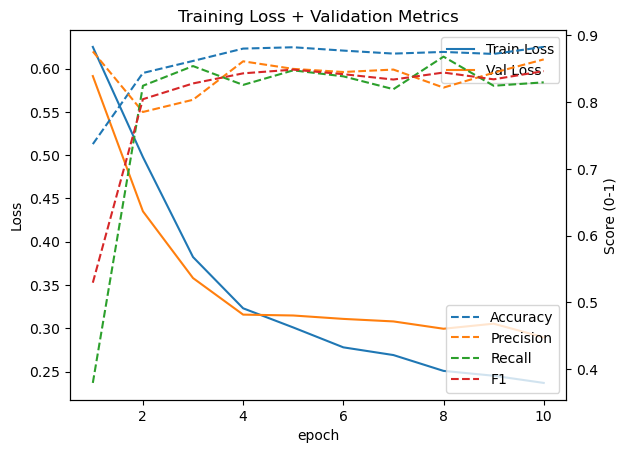

In [40]:
import seaborn as sns

df_history = pd.DataFrame(history)
df_history["epoch"] = range(1, len(df_history) + 1)

fig, ax1 = plt.subplots()

# Loss
sns.lineplot(data=df_history, x="epoch", y="train_loss", ax=ax1, label="Train Loss")
sns.lineplot(data=df_history, x="epoch", y="val_loss", ax=ax1, label="Val Loss")
ax1.set_ylabel("Loss")

# Metrics
ax2 = ax1.twinx()
sns.lineplot(data=df_history, x="epoch", y="val_accuracy", ax=ax2, linestyle="--", label="Accuracy")
sns.lineplot(data=df_history, x="epoch", y="val_precision", ax=ax2, linestyle="--", label="Precision")
sns.lineplot(data=df_history, x="epoch", y="val_recall", ax=ax2, linestyle="--", label="Recall")
sns.lineplot(data=df_history, x="epoch", y="val_f1", ax=ax2, linestyle="--", label="F1")

ax2.set_ylabel("Score (0-1)")

plt.title("Training Loss + Validation Metrics")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1, loc="best")

plt.show()

### Test Function

In [41]:
@torch.no_grad()
def test_rgcn_minibatch(model, test_loader, criterion, device, relation_to_idx, show_cm=True):
    y_true, y_logits, y_probs, y_pred, metrics = evaluate_rgcn_minibatch(
        model, test_loader, criterion, device, relation_to_idx
    )

    print(f"Test Loss:  {metrics['loss']:.4f}")
    print(f"Precision:  {metrics['precision']:.4f}")
    print(f"Recall:     {metrics['recall']:.4f}")
    print(f"Accuracy:   {metrics['accuracy']:.4f}")
    print(f"F1 Score:   {metrics['f1']:.4f}")

    if show_cm:
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap="Blues")
        plt.title("Confusion Matrix")
        plt.show()

    return y_true, y_logits, y_probs, y_pred, metrics

Test Loss:  0.2869
Precision:  0.8714
Recall:     0.8256
Accuracy:   0.8845
F1 Score:   0.8479


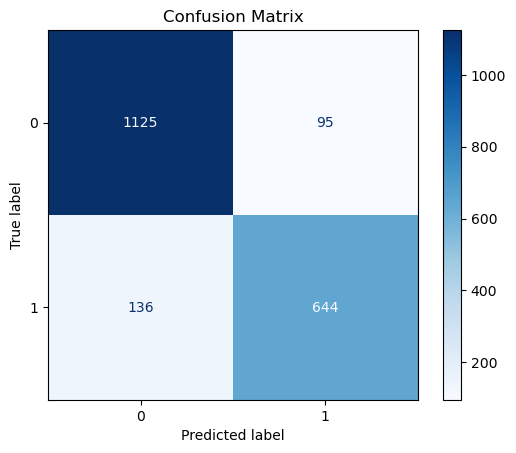

In [42]:
y_true, y_logits, y_probs, y_pred, metrics = test_rgcn_minibatch(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    relation_to_idx=relation_to_idx,
    show_cm=True
)

## Summary statistics
- Validate node count
- Validate edge count
- Validate edge_type count
- Confirm feature dimension
- Confirm split sizes
- Confirm number of relation types

In [43]:
num_nodes_from_mapping = len(user_to_idx)
num_nodes_from_x = data.x.shape[0]
num_labels = data.y.shape[0]
num_edges = data.edge_index.shape[1]
num_edge_types = data.edge_type.shape[0]
num_features = data.x.shape[1]

print("Summary Statistics for mini-batch R-GCN graph")
print(f"Nodes from user_to_idx:   {num_nodes_from_mapping:,}")
print(f"Nodes in data.x:          {num_nodes_from_x:,}")
print(f"Labels in data.y:         {num_labels:,}")
print(f"Edges in data.edge_index: {num_edges:,}")
print(f"Edge types:               {num_edge_types:,}")
print(f"Features per node:        {num_features:,}")
print(f"Relations retained:       {len(relation_to_idx):,}")

print("\nConsistency checks:")
print(f"x matches node mapping:    {num_nodes_from_x == num_nodes_from_mapping}")
print(f"y matches x:               {num_labels == num_nodes_from_x}")
print(f"edge_type matches edges:   {num_edge_types == num_edges}")

print("\nSplit sizes:")
print(f"Train nodes: {int(train_mask.sum()):,}")
print(f"Val nodes:   {int(val_mask.sum()):,}")
print(f"Test nodes:  {int(test_mask.sum()):,}")
print(f"Total split: {(int(train_mask.sum()) + int(val_mask.sum()) + int(test_mask.sum())):,}")

Summary Statistics for mini-batch R-GCN graph
Nodes from user_to_idx:   28,889
Nodes in data.x:          28,889
Labels in data.y:         28,889
Edges in data.edge_index: 43,994,316
Edge types:               43,994,316
Features per node:        395
Relations retained:       9

Consistency checks:
x matches node mapping:    True
y matches x:               True
edge_type matches edges:   True

Split sizes:
Train nodes: 16,000
Val nodes:   2,000
Test nodes:  2,000
Total split: 20,000


## Performance measures

### ROC Curve
A ROC curve can be added here to examine the trade-off between true positive rate and false positive rate across thresholds. This is especially useful when the decision threshold may later be tuned instead of fixed at the default argmax prediction.

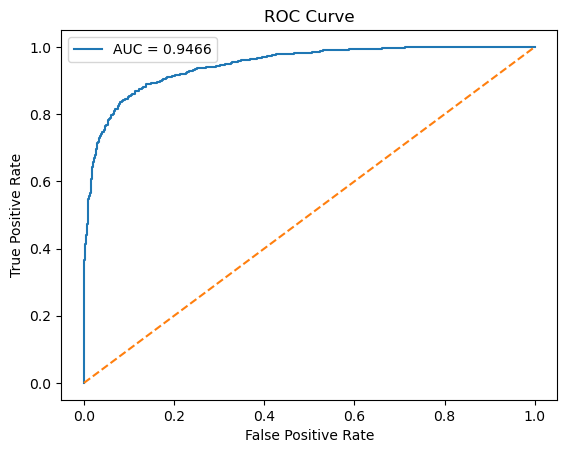

In [44]:
from sklearn.metrics import roc_curve, auc

y_prob_bot = y_probs[:, 1]

fpr, tpr, thresholds = roc_curve(y_true, y_prob_bot)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Comments

The ROC curve demonstrates strong performance, with an AUC of 0.9489, indicating that the model is  effective at distinguishing between bot and human users. The curve rises steeply towards the top-left corner, showing that the model achieves a high true positive rate even at low false positive rates. This suggests that the model can correctly identify a large proportion of bots while maintaining relatively few false alarms.

### Precision-Recall Curve
A precision-recall curve is especially informative for imbalanced bot detection tasks because it focuses directly on the trade-off between retrieving bots and avoiding false positives.

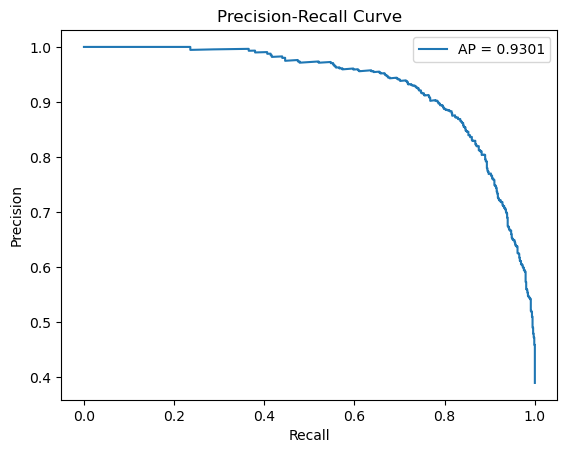

In [45]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_prob_bot)
ap_score = average_precision_score(y_true, y_prob_bot)

plt.figure()
plt.plot(recall_vals, precision_vals, label=f"AP = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

Comments

The Precision–Recall curve further confirms strong performance, with an Average Precision (AP) of 0.9650. Precision remains close to 1.0 across a wide range of recall values, indicating that the model maintains high accuracy in its positive predictions even as it retrieves more bot accounts.

However, as recall approaches 1.0, precision drops more. This reflects the  trade-off where capturing nearly all bots introduces more false positives. Despite this, the overall curve remains high, suggesting that the model performs well even under class imbalance.

### Get predictions and build evaluation table

In [46]:
threshold = 0.5

# Use class-1 probabilities only
y_prob_bot = y_probs[:, 1]

# Hard predictions from threshold
y_pred = (y_prob_bot >= threshold).astype(int)

# Recover test node indices and map back to user IDs
test_node_idx = data.test_mask.nonzero(as_tuple=True)[0].cpu().numpy()
node_to_user = dict(enumerate(df_nodes["user_id"].astype(str)))

# Safety check
print("len(test_node_idx):", len(test_node_idx))
print("len(y_true):", len(y_true))
print("len(y_pred):", len(y_pred))
print("len(y_prob_bot):", len(y_prob_bot))

# Build evaluation table
df_eval = pd.DataFrame({
    "node_idx": test_node_idx,
    "y_true": y_true,
    "y_pred": y_pred,
    "y_prob_bot": y_prob_bot
})

df_eval["error"] = df_eval["y_true"] != df_eval["y_pred"]
df_eval["error_type"] = np.select(
    [
        (df_eval["y_true"] == 0) & (df_eval["y_pred"] == 1),
        (df_eval["y_true"] == 1) & (df_eval["y_pred"] == 0),
        (df_eval["y_true"] == 1) & (df_eval["y_pred"] == 1),
        (df_eval["y_true"] == 0) & (df_eval["y_pred"] == 0),
    ],
    [
        "False Positive",
        "False Negative",
        "True Positive",
        "True Negative"
    ],
    default="Other"
)

df_eval["confidence"] = np.where(
    df_eval["y_pred"] == 1,
    df_eval["y_prob_bot"],
    1 - df_eval["y_prob_bot"]
)

df_eval["distance_from_0.5"] = np.abs(df_eval["y_prob_bot"] - 0.5)

# Merge with user metadata
df_eval["user_id"] = df_eval["node_idx"].map(node_to_user)

df_user_copy = df_user.copy()
df_user_copy["id"] = df_user_copy["id"].astype(str)

df_eval = df_eval.merge(
    df_user_copy,
    left_on="user_id",
    right_on="id",
    how="left"
)

# Misclassified users only
df_errors = df_eval[df_eval["error"]].copy()

print("df_eval shape:", df_eval.shape)
print("df_errors shape:", df_errors.shape)
df_errors.head(10)

len(test_node_idx): 2000
len(y_true): 2000
len(y_pred): 2000
len(y_prob_bot): 2000
df_eval shape: (2000, 408)
df_errors shape: (231, 408)


,node_idx,y_true,y_pred,y_prob_bot,error,error_type,confidence,distance_from_0.5,user_id,id,label,split,participation_degree,pinned_tweet_id,protected,verified,followers_count,following_count,tweet_count,listed_count,has_pinned_tweet,account_age_days,has_description,has_location,has_url,has_profile_image,profile_completeness_score,log_followers_following_ratio,log_following_followers_ratio,log_tweets_followers_ratio,log_tweets_following_ratio,log_listed_followers_ratio,log_normalized_followers,log_normalized_following,log_normalized_tweets,log_normalized_listed,average_tweets_per_day,log_tweets_per_day_relative_to_age,log_tweet_engagement_ratio,high_activity_low_followers,high_tweet_low_age,is_low_follower_high_activity,new_account_high_tweets,follows_more_than_followed,is_new_with_verified,account_age_category,description_length,username_length,description_word_count,has_url_in_description,username_digit_ratio,description_digit_ratio,description_special_chars_count,description_uppercase_ratio,username_special_chars_ratio,follower_following_disparity,description_spam_score,username_digit_count,username_upper_ratio,username_special_char_ratio,username_underscore_count,name_length,name_word_count,name_digit_count,name_upper_ratio,description_digit_count,description_upper_ratio,description_special_char_ratio,desc_tfidf_2021,desc_tfidf_2022,desc_tfidf_account,desc_tfidf_advice,desc_tfidf_advisor,desc_tfidf_advocate,desc_tfidf_ai,desc_tfidf_alum,desc_tfidf_ambassador,desc_tfidf_american,desc_tfidf_analysis,desc_tfidf_analyst,desc_tfidf_analytics,desc_tfidf_anti,desc_tfidf_art,desc_tfidf_artificial,desc_tfidf_artist,desc_tfidf_assistant,desc_tfidf_assistant professor,desc_tfidf_associate,desc_tfidf_associate professor,desc_tfidf_author,desc_tfidf_award,desc_tfidf_based,desc_tfidf_best,desc_tfidf_better,desc_tfidf_bitcoin,desc_tfidf_black,desc_tfidf_blockchain,desc_tfidf_blog,desc_tfidf_blogger,desc_tfidf_board,...,desc_tfidf_security,desc_tfidf_self,desc_tfidf_senior,desc_tfidf_service,desc_tfidf_services,desc_tfidf_share,desc_tfidf_sharing,desc_tfidf_social,desc_tfidf_social media,desc_tfidf_society,desc_tfidf_software,desc_tfidf_software engineer,desc_tfidf_solutions,desc_tfidf_source,desc_tfidf_space,desc_tfidf_speaker,desc_tfidf_sports,desc_tfidf_stanford,desc_tfidf_startups,desc_tfidf_state,desc_tfidf_student,desc_tfidf_studying,desc_tfidf_stuff,desc_tfidf_support,desc_tfidf_systems,desc_tfidf_teacher,desc_tfidf_team,desc_tfidf_tech,desc_tfidf_technology,desc_tfidf_things,desc_tfidf_time,desc_tfidf_tips,desc_tfidf_trader,desc_tfidf_travel,desc_tfidf_trying,desc_tfidf_tv,desc_tfidf_tweet,desc_tfidf_tweets,desc_tfidf_twitter,desc_tfidf_twitter account,desc_tfidf_uk,desc_tfidf_university,desc_tfidf_unknown,desc_tfidf_updates,desc_tfidf_views,desc_tfidf_vision,desc_tfidf_voice,desc_tfidf_way,desc_tfidf_web,desc_tfidf_website,desc_tfidf_winning,desc_tfidf_women,desc_tfidf_work,desc_tfidf_working,desc_tfidf_world,desc_tfidf_write,desc_tfidf_writer,desc_tfidf_writing,desc_tfidf_york,desc_tfidf_youtube,tweets,has_tweets,num_tweets,tweets_frequency,posting_regularity,avg_length_per_tweet,avg_words_per_tweet,avg_word_length_per_tweet,avg_uppercase_pct,avg_digit_pct,avg_special_char_pct,avg_emoji,avg_hashtags_per_tweet,overuse_hashtags,pct_tweets_with_hashtags,avg_mentions_per_tweet,pct_tweets_with_mentions,avg_urls_per_tweet,pct_tweets_with_urls,avg_attachments_per_tweet,pct_tweets_with_attachments,avg_sensitive,avg_positive,avg_negative,avg_neutral,avg_retweets,avg_quotes,avg_replies,avg_originals,avg_likes_per_tweet,avg_retweets_per_tweet,avg_replies_per_tweet,avg_quotes_per_tweet,engagement_rate,pct_allow_reply,fc_reply,num_unique_langs,pct_geo_tweets,has_reply_inconsistency,reply_inconsistency_count
1,37,0,1,0.521668,True,False Positive,0.521668,0.021668,u781673283829788672,u781673283829788672,human,train,1075,NaN,0,0,178,1350,534,1,0,1968,1,0,0,1,2,-2.021215,2.021215,1.094881,-0.926334,-4.494239,-2.398403,-0.377188,-1.303522,-6.8926

### Core evaluation metrics

In [47]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    brier_score_loss
)

# Positive-class probabilities only
y_prob_bot = y_probs[:, 1]

print("=" * 60)
print("TEST SET CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, digits=4))

print("=" * 60)
print("CORE PERFORMANCE METRICS")
print("=" * 60)
print(f"ROC-AUC:            {roc_auc_score(y_true, y_prob_bot):.4f}")
print(f"PR-AUC / AP:        {average_precision_score(y_true, y_prob_bot):.4f}")
print(f"Precision:          {precision_score(y_true, y_pred):.4f}")
print(f"Recall:             {recall_score(y_true, y_pred):.4f}")
print(f"F1 Score:           {f1_score(y_true, y_pred):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"Brier Score:        {brier_score_loss(y_true, y_prob_bot):.4f}")


print("=" * 60)
print("ERROR TYPE COUNTS")
print("=" * 60)
print(df_eval["error_type"].value_counts())

print("=" * 60)
print("CONFIDENCE SUMMARY BY ERROR TYPE")
print("=" * 60)
print(
    df_eval.groupby("error_type")[["confidence", "distance_from_0.5"]]
    .agg(["mean", "median", "min", "max", "count"])
    .round(4)
)

TEST SET CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.8921    0.9221    0.9069      1220
           1     0.8714    0.8256    0.8479       780

    accuracy                         0.8845      2000
   macro avg     0.8818    0.8739    0.8774      2000
weighted avg     0.8841    0.8845    0.8839      2000

CORE PERFORMANCE METRICS
ROC-AUC:            0.9466
PR-AUC / AP:        0.9301
Precision:          0.8714
Recall:             0.8256
F1 Score:           0.8479
Balanced Accuracy:  0.8739
Brier Score:        0.0866
ERROR TYPE COUNTS
error_type
True Negative     1125
True Positive      644
False Negative     136
False Positive      95
Name: count, dtype: int64
CONFIDENCE SUMMARY BY ERROR TYPE
               confidence                               distance_from_0.5                              
                     mean  median     min     max count              mean  median     min     max count
error_type                              

### Misclassified User Metadata Profiling

TOP 10 MOST OVERCONFIDENT MISTAKES


,user_id,y_true,y_pred,y_prob_bot,confidence,error_type
423,u18027886,1,0,0.013889,0.986111,False Negative
358,u992153930095251456,1,0,0.016475,0.983525,False Negative
919,u3018222517,1,0,0.017967,0.982033,False Negative
1377,u87615624,1,0,0.020936,0.979064,False Negative
168,u1142961546403950592,1,0,0.026159,0.973841,False Negative
1536,u50882754,1,0,0.029514,0.970486,False Negative
814,u203824292,1,0,0.030136,0.969864,False Negative
1444,u12916,1,0,0.039470,0.960530,False Negative
1301,u1261682787784032257,1,0,0.040349,0.959651,False Negative
148,u304822355,1,0,0.040731,0.959269,False Negative


TOP 10 MOST AMBIGUOUS MISTAKES


,user_id,y_true,y_pred,y_prob_bot,distance_from_0.5,error_type
289,u839503112,1,0,0.498533,0.001467,False Negative
1807,u110874872,0,1,0.501535,0.001535,False Positive
1898,u26622137,1,0,0.497881,0.002119,False Negative
226,u1479053350062723073,1,0,0.495785,0.004215,False Negative
362,u1018931868564180993,0,1,0.504570,0.004570,False Positive
269,u727767097879764993,0,1,0.506300,0.006300,False Positive
528,u1264862081301520384,0,1,0.506634,0.006634,False Positive
858,u17598719,1,0,0.491263,0.008737,False Negative
1746,u987086862,1,0,0.488658,0.011342,False Negative
1906,u864120714739068928,1,0,0.488035,0.011965,False Negative


Top differentiating features between FP and FN:
['posting_regularity', 'tweet_count', 'following_count', 'followers_count', 'follower_following_disparity', 'account_age_days', 'avg_retweets_per_tweet', 'participation_degree', 'avg_likes_per_tweet', 'listed_count']


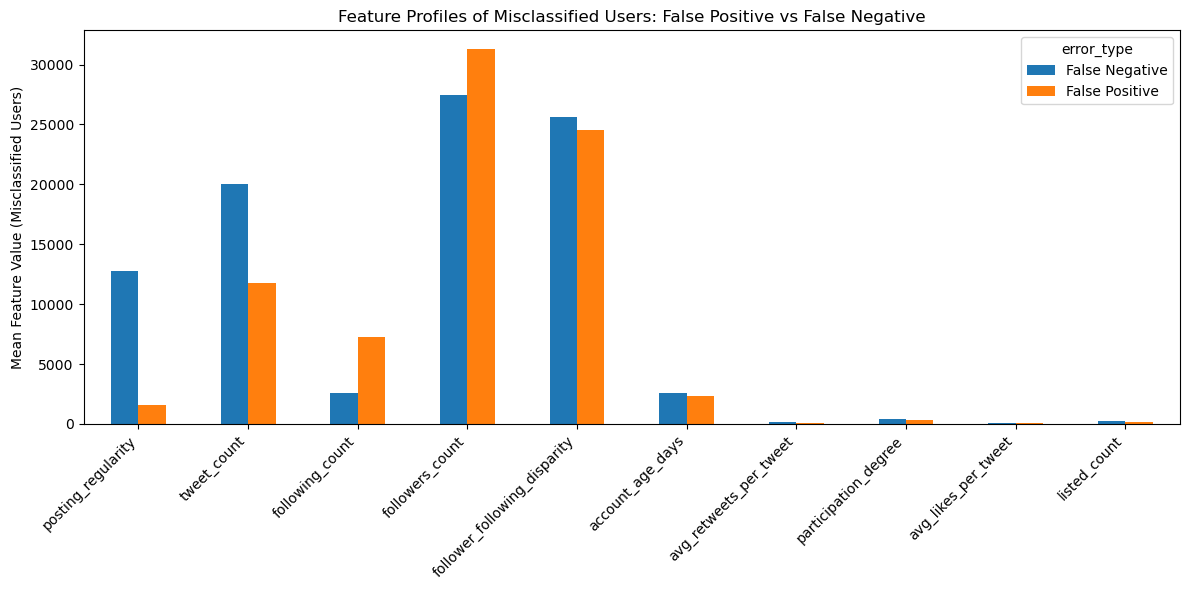

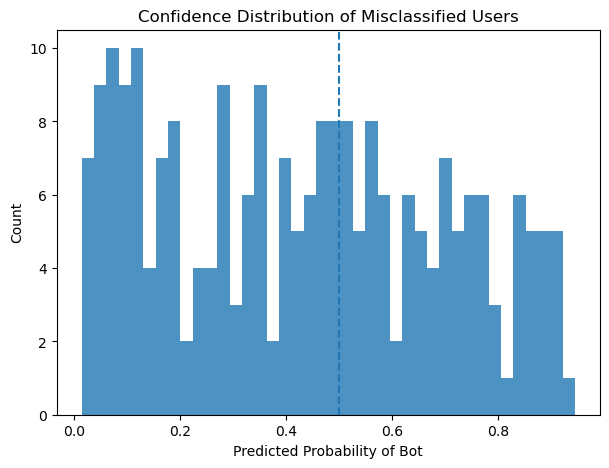

In [48]:
# 1. Show most overconfident and most ambiguous mistakes
print("=" * 60)
print("TOP 10 MOST OVERCONFIDENT MISTAKES")
print("=" * 60)
display(
    df_errors.sort_values("confidence", ascending=False).head(10)[
        ["user_id", "y_true", "y_pred", "y_prob_bot", "confidence", "error_type"]
    ]
)

print("=" * 60)
print("TOP 10 MOST AMBIGUOUS MISTAKES")
print("=" * 60)
display(
    df_errors.sort_values("distance_from_0.5", ascending=True).head(10)[
        ["user_id", "y_true", "y_pred", "y_prob_bot", "distance_from_0.5", "error_type"]
    ]
)

# 2. Dynamically find top differentiating numeric features
feature_cols = df_errors.select_dtypes(include=np.number).columns.tolist()

exclude_cols = {
    "node_idx", "y_true", "y_pred", "y_prob_bot", "error", "confidence", "distance_from_0.5"
}

feature_cols = [
    c for c in feature_cols
    if c not in exclude_cols
    and "id" not in c.lower()
    and not c.startswith("desc_tfidf")
]

df_fp = df_errors[df_errors["error_type"] == "False Positive"]
df_fn = df_errors[df_errors["error_type"] == "False Negative"]

valid_cols = [
    c for c in feature_cols
    if df_fp[c].notna().sum() > 0 and df_fn[c].notna().sum() > 0
]

mean_diff = (df_fp[valid_cols].mean() - df_fn[valid_cols].mean()).abs()
top_features = mean_diff.sort_values(ascending=False).head(10).index.tolist()

print("Top differentiating features between FP and FN:")
print(top_features)

# 3. Plot feature profiles of misclassified users
summary = df_errors.groupby("error_type")[top_features].mean()

summary.T.plot(kind="bar", figsize=(12, 6))
plt.title("Feature Profiles of Misclassified Users: False Positive vs False Negative")
plt.ylabel("Mean Feature Value (Misclassified Users)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 4. Confidence distribution of misclassified users
plt.figure(figsize=(7, 5))
plt.hist(df_errors["y_prob_bot"], bins=40, alpha=0.8)
plt.axvline(0.5, linestyle="--")
plt.xlabel("Predicted Probability of Bot")
plt.ylabel("Count")
plt.title("Confidence Distribution of Misclassified Users")
plt.show()

### Misclassified User In-degree, Out-degree, Edge Relation Type Profiling

GRAPH PROFILE SUMMARY FOR MISCLASSIFIED USERS


in_degree                          out_degree                          total_degree                         
                    mean  median min    max count       mean  median min    max count         mean  median min    max count
error_type                                                                                                                 
False Negative   1939.96  1060.0   0  11131   136    1951.19  1079.5   0  11103   136      3891.15  2148.0   0  22234   136
False Positive   2007.00  1073.0   0   7431    95    2025.15  1186.0   0   7415    95      4032.15  2146.0   1  14846    95

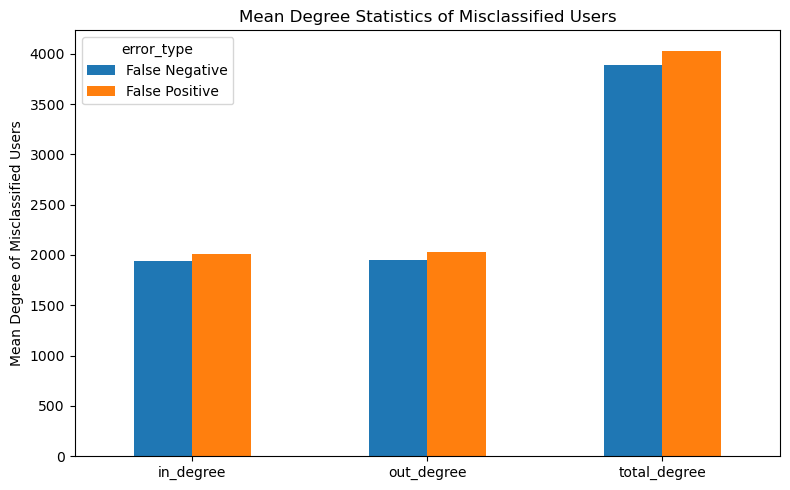

TOP RELATION-TYPE DEGREE DIFFERENCES (FP vs FN)


error_type,False Negative,False Positive,abs_diff
discuss_same_topic_total_degree,3853.51,4002.04,148.53
mentions_total_degree,8.79,3.23,5.56
following_total_degree,19.54,23.08,3.54
retweets_total_degree,3.85,1.61,2.24
replies_to_total_degree,1.41,0.45,0.96
likes_total_degree,1.89,1.15,0.74
quotes_total_degree,1.04,0.31,0.73
member_of_communities_owned_by_total_degree,0.72,0.21,0.51
owner_of_communities_frequent_by_total_degree,0.40,0.06,0.34


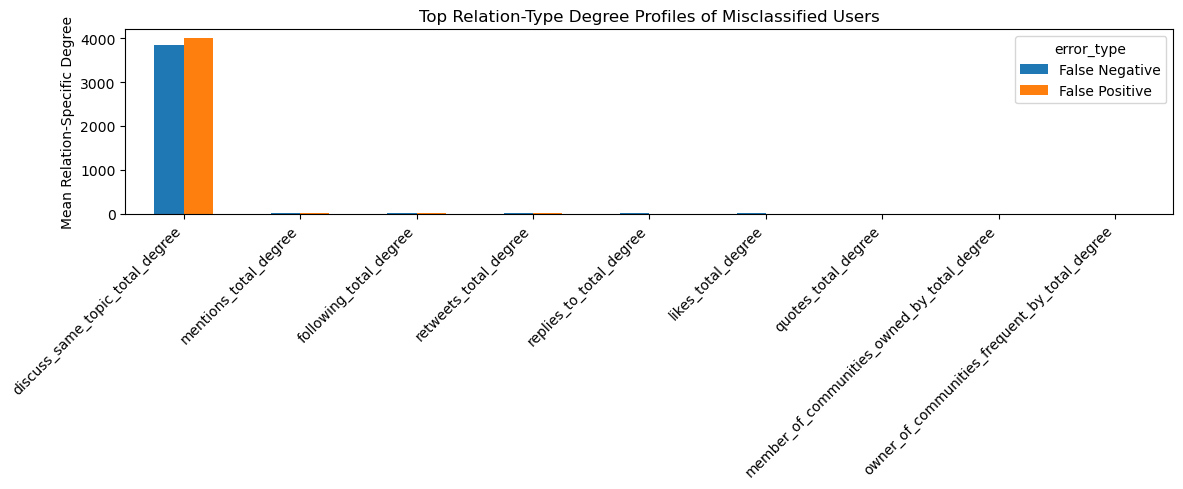

TOP 15 OVERCONFIDENT MISCLASSIFIED USERS WITH GRAPH STATS


,user_id,error_type,y_true,y_pred,y_prob_bot,confidence,in_degree,out_degree,total_degree
423,u18027886,False Negative,1,0,0.013889,0.986111,1483,1337,2820
358,u992153930095251456,False Negative,1,0,0.016475,0.983525,3744,3528,7272
919,u3018222517,False Negative,1,0,0.017967,0.982033,1131,1100,2231
1377,u87615624,False Negative,1,0,0.020936,0.979064,3385,3373,6758
168,u1142961546403950592,False Negative,1,0,0.026159,0.973841,3772,3852,7624
1536,u50882754,False Negative,1,0,0.029514,0.970486,1443,1441,2884
814,u203824292,False Negative,1,0,0.030136,0.969864,9336,9336,18672
1444,u12916,False Negative,1,0,0.039470,0.960530,4598,4592,9190
1301,u1261682787784032257,False Negative,1,0,0.040349,0.959651,13,1,14
148,u304822355,False Negative,1,0,0.040731,0.959269,4937,5105,10042


In [49]:
# 1. Build graph-level degree statistics from full graph
edge_index_cpu = data.edge_index.cpu()
edge_type_cpu = data.edge_type.cpu().numpy()

src = edge_index_cpu[0].numpy()
dst = edge_index_cpu[1].numpy()

num_nodes = data.num_nodes
idx_to_relation = {v: k for k, v in relation_to_idx.items()}

# Basic degree features
out_degree = np.bincount(src, minlength=num_nodes)
in_degree = np.bincount(dst, minlength=num_nodes)
total_degree = out_degree + in_degree

# Per-relation degree counts
relation_degree_dict = {}
for rel_idx, rel_name in idx_to_relation.items():
    mask = edge_type_cpu == rel_idx
    src_rel = src[mask]
    dst_rel = dst[mask]

    out_rel = np.bincount(src_rel, minlength=num_nodes)
    in_rel = np.bincount(dst_rel, minlength=num_nodes)

    relation_degree_dict[f"{rel_name}_out_degree"] = out_rel
    relation_degree_dict[f"{rel_name}_in_degree"] = in_rel
    relation_degree_dict[f"{rel_name}_total_degree"] = out_rel + in_rel


# 2. Attach graph stats to df_eval / df_errors
df_eval_graph = df_eval.copy()

df_eval_graph["in_degree"] = in_degree[df_eval_graph["node_idx"].values]
df_eval_graph["out_degree"] = out_degree[df_eval_graph["node_idx"].values]
df_eval_graph["total_degree"] = total_degree[df_eval_graph["node_idx"].values]

for col_name, arr in relation_degree_dict.items():
    df_eval_graph[col_name] = arr[df_eval_graph["node_idx"].values]

df_errors_graph = df_eval_graph[df_eval_graph["error"]].copy()

# 3. Summary table: graph stats by error type
basic_graph_cols = ["in_degree", "out_degree", "total_degree"]

print("=" * 70)
print("GRAPH PROFILE SUMMARY FOR MISCLASSIFIED USERS")
print("=" * 70)
display(
    df_errors_graph.groupby("error_type")[basic_graph_cols]
    .agg(["mean", "median", "min", "max", "count"])
    .round(2)
)

# 4. Bar chart: FP vs FN mean graph stats
summary_basic = (
    df_errors_graph.groupby("error_type")[basic_graph_cols]
    .mean()
    .round(2)
)

summary_basic.T.plot(kind="bar", figsize=(8, 5))
plt.title("Mean Degree Statistics of Misclassified Users")
plt.ylabel("Mean Degree of Misclassified Users")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. Relation-type summary table for FP vs FN
relation_total_cols = [c for c in df_errors_graph.columns if c.endswith("_total_degree")]

relation_summary = (
    df_errors_graph.groupby("error_type")[relation_total_cols]
    .mean()
    .T
    .round(2)
)

# Show only top 10 most differentiating relation stats
if {"False Positive", "False Negative"}.issubset(relation_summary.columns):
    relation_summary["abs_diff"] = (
        relation_summary["False Positive"] - relation_summary["False Negative"]
    ).abs()
    relation_summary_top = relation_summary.sort_values("abs_diff", ascending=False).head(10)
else:
    relation_summary_top = relation_summary.head(10)

print("=" * 70)
print("TOP RELATION-TYPE DEGREE DIFFERENCES (FP vs FN)")
print("=" * 70)
display(relation_summary_top)

# 6. Plot top relation-type graph differences
plot_cols = [c for c in relation_summary_top.columns if c != "abs_diff"]
relation_summary_top[plot_cols].plot(kind="bar", figsize=(12, 5))
plt.title("Top Relation-Type Degree Profiles of Misclassified Users")
plt.ylabel("Mean Relation-Specific Degree")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# 7. Table of top overconfident mistakes with graph stats
print("=" * 70)
print("TOP 15 OVERCONFIDENT MISCLASSIFIED USERS WITH GRAPH STATS")
print("=" * 70)

cols_to_show = [
    "user_id", "error_type", "y_true", "y_pred", "y_prob_bot",
    "confidence", "in_degree", "out_degree", "total_degree"
]

display(
    df_errors_graph.sort_values("confidence", ascending=False)[cols_to_show].head(15)
)